In [32]:
import sys
from pathlib import Path
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev
from uncertainties.core import CallableStdDev
import plotly.express as px

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
main_scale_up_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"
percent_ecw_scale_up_path = BASE_DIR / "results" / "Scale_up_PERCENT_ECW_POLL_MS.csv"

cr_man_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_MAN_MS.csv"
cr_repur_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_REPUR_MS.csv"
cr_stock_scale_up_path = BASE_DIR / "results" / "Scale_up_CR_STOCK.csv"
coalbag_scale_up_path = BASE_DIR / "results" / "Scale_up_COALBAG_MS.csv"

ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"

In [41]:
# ---------- Core Functions ----------

def get_series(df, region):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    if region not in df.index:
        raise ValueError(f"{region} not found in DataFrame index")

    row = df.loc[region]  # Series of ufloats
    row = row.iloc[2:]
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors

def get_ECW(df, region):
    row = df.loc[region]
    ECW_Upper = row[1]
    ECW_Lower = row[0]
    return ECW_Lower, ECW_Upper

def plot_region(df, region, ax=None, sigma=1, show_CADR=True):
    """Plot a single country's series with ±sigma bands and optional CADR range."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t, vals, errs = get_series(df, region)

    if show_CADR:
        ecw_lower, ecw_upper = get_ECW(df, region)
        CADR_lower = CADRPP * ecw_lower
        CADR_upper = CADRPP * ecw_upper
        ax.axhspan(CADR_lower, CADR_upper, alpha=0.15, 
                   label=f'CADR Range ({CADR_lower:.1f}-{CADR_upper:.1f})')
    
    if not show_CADR: ax.set_ylim(0,1)
    ax.plot(t, vals, label=region)
    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, alpha=0.3)
    ax.set_title(f"{region} Scale Up with ±{sigma}σ bands ")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax

def plot_multiple_regions(df, region, sigma=1, show_CADR=True):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in region:
        plot_region(df, c, ax=ax, sigma=sigma, show_CADR = show_CADR)
    plt.title(f"Multiple Regions series with ±{sigma}σ bands")
    plt.show()

def plot_stacked_regions(df1, df2, df3, df4, region, ax=None):
    'Plot a stacked area chart for 4 dataframes for a given region.'
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    # Get series from each dataframe
    t1, vals1, _ = get_series(df1, region)
    t2, vals2, _ = get_series(df2, region)
    t3, vals3, _ = get_series(df3, region)
    t4, vals4, _ = get_series(df4, region)
    
    # Ensure all time indices are the same
    t = t1  # assume all dfs have the same weeks
    
    # Stack values as a list of arrays
    stack_vals = [vals1, vals2, vals3, vals4]
    
    # Default labels if not provided
    labels = ['CR Box Repurposing', 'CR Box Stock', 'Coalbaghouse','CR Box Manufacturing']
    
    # Plot stacked area
    ax.stackplot(t, *stack_vals, labels=labels, alpha=0.6)
    
    ax.set_title(f"{region} - Stacked Area Chart")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend(loc='upper left')
    
    return ax



In [42]:
## ---------------------------- Varaibles ---------------------------- 

CADRPP = 100 # L/s
UNRegion_list = ['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

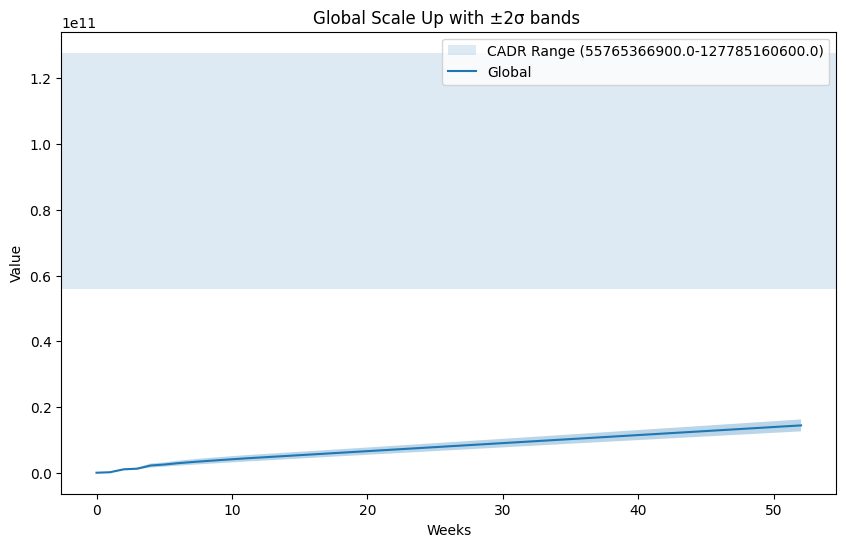

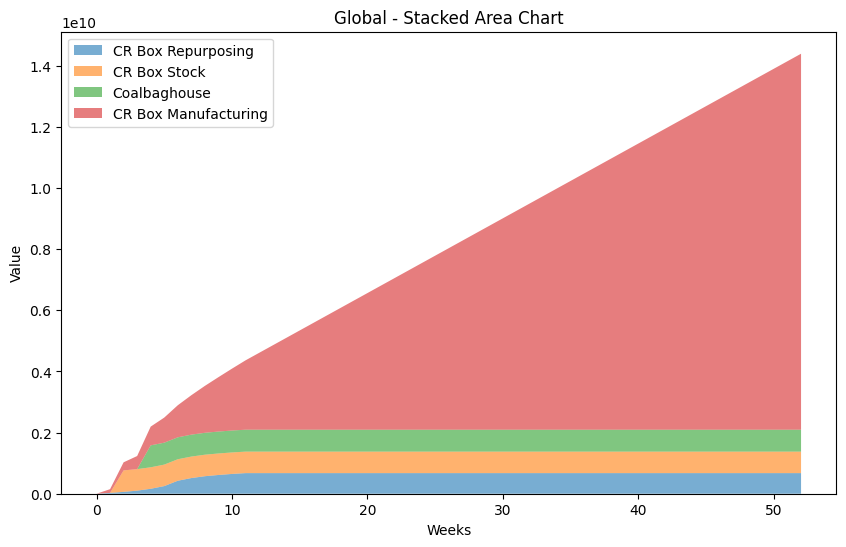

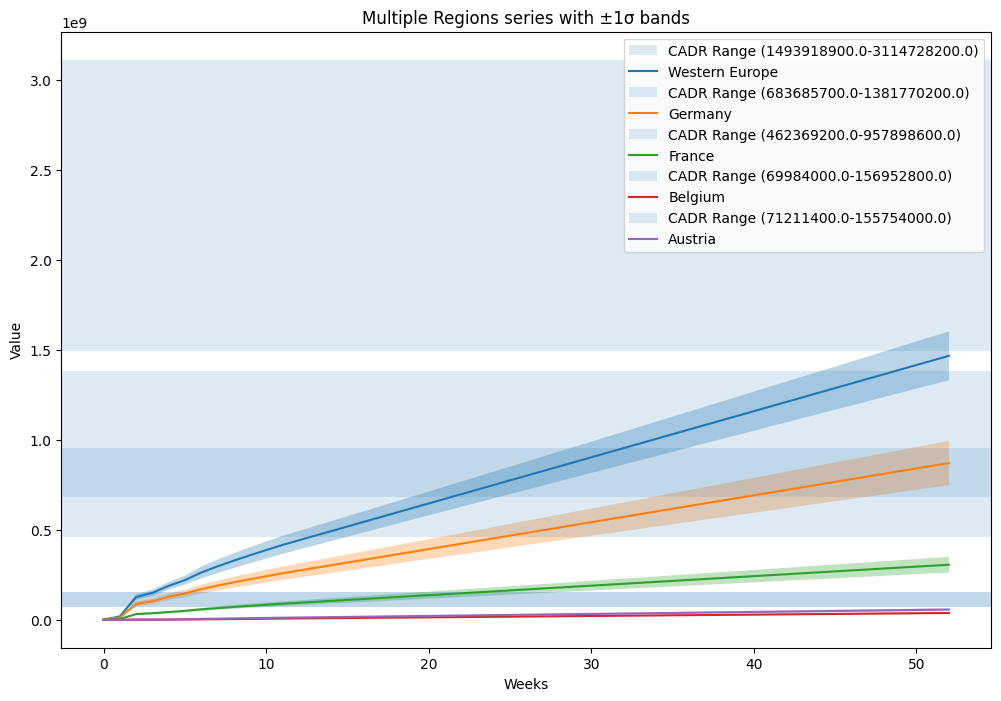

In [43]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 
df_MAIN_loaded = pd.read_pickle(main_scale_up_path.with_suffix(".pkl"))
df_PERCENT_ECW_LOADED = pd.read_pickle(percent_ecw_scale_up_path.with_suffix(".pkl"))

df_CR_REPUR_loaded = pd.read_pickle(cr_repur_scale_up_path.with_suffix(".pkl"))
df_CR_STOCK_loaded = pd.read_pickle(cr_stock_scale_up_path.with_suffix(".pkl"))
df_COALBAG_loaded = pd.read_pickle(coalbag_scale_up_path.with_suffix(".pkl"))
df_CR_MAN_loaded = pd.read_pickle(cr_man_scale_up_path.with_suffix(".pkl"))

plot_region(df_MAIN_loaded, "Global", sigma=2, show_CADR=True)
# plot_region(df_PERCENT_ECW_LOADED, "Australia", sigma=2, show_CADR=False)
plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, "Global")

plot_multiple_regions(df_MAIN_loaded, ['Western Europe', "Germany", 'France', 'Belgium', "Austria"], sigma =1, show_CADR=True)

# for i in UNRegion_list:
    # plot_region(df_MAIN_loaded, i, sigma=1)
#     plot_stacked_regions(df_CR_REPUR_loaded, df_CR_STOCK_loaded, df_COALBAG_loaded, df_CR_MAN_loaded, i)



In [36]:
## ---------------------------- Choropleth Plotting ---------------------------- 

time_to_reach_scale_up_path = BASE_DIR / "results" / "TTR_Region_MS.csv"

df_CHOROPETH_loaded = pd.read_csv(time_to_reach_scale_up_path)

from UNregionChoroplethGenerator import create_un_region_choropleth

fig = create_un_region_choropleth(df_CHOROPETH_loaded,region_col='Region', value_col='Weeks')
fig.show()

KeyError: 'Weeks'